In [ ]:
import pandas as pd
import numpy as np



In [ ]:
df= pd.read_csv("BostonHousing.csv")

In [ ]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [ ]:
x = df[['crim', 'indus']]
x

,crim,indus
0,0.00632,2.31
1,0.02731,7.07
2,0.02729,7.07
3,0.03237,2.18
4,0.06905,2.18
...,...,...
501,0.06263,11.93
502,0.04527,11.93
503,0.06076,11.93
504,0.10959,11.93


In [ ]:
y = df[['medv']]
y

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [ ]:
import pandas as pd

def trim(col: pd.Series):
    lower_limit = col.mean() - 3 * col.std()
    upper_limit = col.mean() + 3 * col.std()
    # Usually you'll want to return something or apply the mask here
    new_col=col[(col > lower_limit) & (col < upper_limit)]
    return new_col

In [ ]:
trimmed_crim = trim (df["crim"])
trimmed_indus = trim (df["indus"])
trimmed_medv= trim (df["medv"])

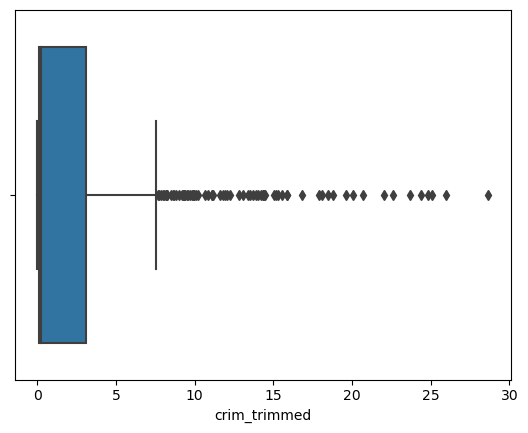

In [ ]:
df['crim_trimmed'] = trim(df['crim'])

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['crim_trimmed'])
plt.show()

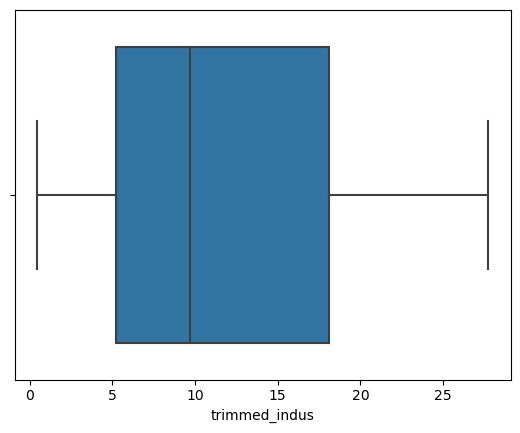

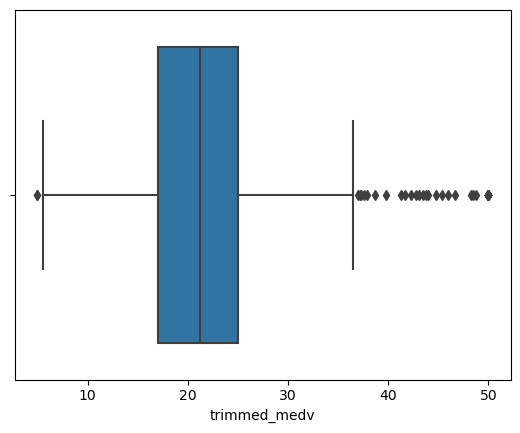

In [ ]:
df['trimmed_indus'] = trim(df['indus'])
sns.boxplot(x=df['trimmed_indus'])

plt.show()

df['trimmed_medv'] = trim(df['medv'])
sns.boxplot(x=df['trimmed_medv'])

plt.show()

In [ ]:
#model selection
from  sklearn.model_selection import train_test_split

x = df[['crim','indus']]
y = df[['medv']]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25)



#standardizing dataset
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

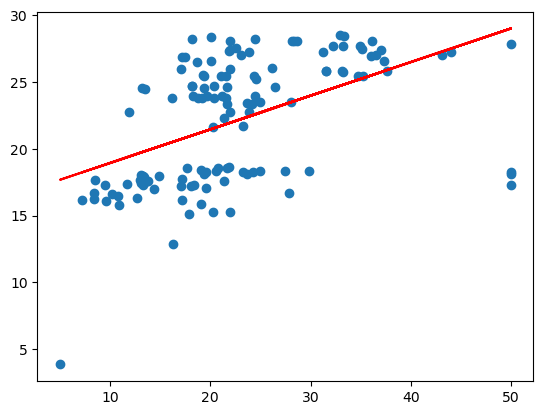

In [ ]:
from sklearn import linear_model
#creating model
model = linear_model.LinearRegression()
model.fit(x_train,y_train)


y_pred = model.predict(x_test)
plt.scatter(y_test,y_pred)
y_test_1 = y_test.values.flatten()
y_pred_1 = y_pred.flatten()

m,b = np.polyfit(y_test_1,y_pred_1,1)
plt.plot(y_test_1,m*y_test_1+b,color='red')
plt.show()



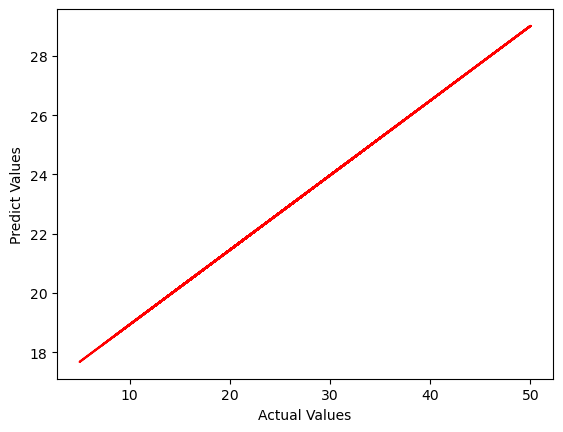

In [ ]:
m,b= np.polyfit(y_test_1,y_pred_1,1)
plt.plot(y_test_1,m*y_test_1 + b,color='red')
plt.xlabel("Actual Values")
plt.ylabel("Predict Values")
plt.show()